<a href="https://www.kaggle.com/code/shamanthakreddymallu/s6e6-xgboost-0-96586?scriptVersionId=327183631" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Imports & Load

In [1]:
# PATHS
TRAIN_PATH    = '/kaggle/input/competitions/playground-series-s6e6/train.csv'
TEST_PATH     = '/kaggle/input/competitions/playground-series-s6e6/test.csv'
ORIGINAL_PATH = '/kaggle/input/datasets/fedesoriano/stellar-classification-dataset-sdss17/star_classification.csv'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (balanced_accuracy_score, confusion_matrix,
                             classification_report)
from sklearn.calibration import calibration_curve
from itertools import product
from scipy.optimize import minimize

import warnings
warnings.filterwarnings('ignore')

train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
original = pd.read_csv(ORIGINAL_PATH)

# Standardise original
original = original.rename(columns={'class': 'class'})
original['class'] = original['class'].str.upper().str.strip()

CLASS_COLORS = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}
CLASS_ORDER  = ['GALAXY', 'QSO', 'STAR']

print('Loaded.')
print(f'Train: {train.shape} | Test: {test.shape} | Original: {original.shape}')

Loaded.
Train: (577347, 12) | Test: (247435, 11) | Original: (100000, 18)


# Clean Original Dataset

In [3]:
SENTINEL = -9999
SENTINEL_COLS = ['u', 'g', 'z']  # confirmed from EDA (std >> normal range)

# How many rows are affected?
for col in SENTINEL_COLS:
    n = (original[col] < -100).sum()
    print(f'Original {col}: {n:,} sentinel rows ({n/len(original)*100:.1f}%)')

# Remove rows where ANY sentinel is present
mask_clean = ~((original['u'] < -100) | (original['g'] < -100) | (original['z'] < -100))
original_clean = original[mask_clean].copy()
print(f'\nOriginal after cleaning: {len(original_clean):,} rows '
      f'(removed {len(original) - len(original_clean):,})')

# Verify cleaned distributions look sane
print('\nOriginal (cleaned) numeric stats:')
print(original_clean[['u','g','r','i','z','redshift']].describe().T.round(3))

Original u: 1 sentinel rows (0.0%)
Original g: 1 sentinel rows (0.0%)
Original z: 1 sentinel rows (0.0%)

Original after cleaning: 99,999 rows (removed 1)

Original (cleaned) numeric stats:
            count    mean    std     min     25%     50%     75%     max
u         99999.0  22.081  2.251  10.996  20.352  22.179  23.687  32.781
g         99999.0  20.632  2.037  10.498  18.965  21.100  22.124  31.602
r         99999.0  19.646  1.855   9.822  18.136  20.125  21.045  29.572
i         99999.0  19.085  1.758   9.470  17.732  19.405  20.397  32.141
z         99999.0  18.769  1.766   9.612  17.461  19.005  19.921  29.384
redshift  99999.0   0.577  0.731  -0.010   0.055   0.424   0.704   7.011


# Feature Engineering

## Feature Engineering Function

In [4]:
# Fit empirical stellar locus before any feature engineering
# Using raw train STARs in low-redshift zone
_stars  = train[(train['class'] == 'STAR') & (train['redshift'] < 0.15)]
_ug     = _stars['u'] - _stars['g']
_gr     = _stars['g'] - _stars['r']
_coeffs = np.polyfit(_ug, _gr, deg=1)
LOCUS_A, LOCUS_B = float(_coeffs[0]), float(_coeffs[1])
print(f'Stellar locus fitted: g_r = {LOCUS_A:.4f} * u_g + {LOCUS_B:.4f}')

PHOTO_COLS = ['u', 'g', 'r', 'i', 'z']

def engineer_features(df, locus_a=LOCUS_A, locus_b=LOCUS_B):
    df = df.copy()

    # Group 1: Redshift Transforms
    df['log1p_redshift'] = np.log1p(df['redshift'].clip(lower=0))
    df['redshift_sq']    = df['redshift'] ** 2
    df['is_blueshift']   = (df['redshift'] < 0).astype(int)
    df['redshift_zone']  = pd.cut(
        df['redshift'],
        bins=[-np.inf, 0.0, 0.15, 0.50, 1.0, 1.3, np.inf],
        labels=[0, 1, 2, 3, 4, 5]
    ).astype(int)

    # Group 2: Color Indices
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['u_z'] = df['u'] - df['z']
    df['g_i'] = df['g'] - df['i']
    df['g_z'] = df['g'] - df['z']
    df['r_z'] = df['r'] - df['z']

    # Group 3: Magnitude Summary Stats
    df['mean_mag']  = df[PHOTO_COLS].mean(axis=1)
    df['mag_range'] = df[PHOTO_COLS].max(axis=1) - df[PHOTO_COLS].min(axis=1)
    df['mag_std']   = df[PHOTO_COLS].std(axis=1)

    # Group 4: Interaction Features
    df['redshift_x_gr']     = df['redshift'] * df['g_r']
    df['redshift_x_ug']     = df['redshift'] * df['u_g']
    df['redshift_x_uz']     = df['redshift'] * df['u_z']
    df['log_redshift_x_gr'] = df['log1p_redshift'] * df['g_r']

    # Group 5: Positional — redshift-scaled Cartesian
    alpha_rad = np.radians(df['alpha'])
    delta_rad = np.radians(df['delta'])
    r_dist    = df['log1p_redshift']
    df['phys_x'] = r_dist * np.cos(delta_rad) * np.cos(alpha_rad)
    df['phys_y'] = r_dist * np.cos(delta_rad) * np.sin(alpha_rad)
    df['phys_z'] = r_dist * np.sin(delta_rad)

    # Group 6: Stellar Locus + Low-z Zone Features
    df['locus_gr_pred']  = locus_a * df['u_g'] + locus_b
    df['locus_distance'] = df['g_r'] - df['locus_gr_pred']
    df['locus_dist_abs'] = df['locus_distance'].abs()

    return df

train          = engineer_features(train)
test           = engineer_features(test)
original_clean = engineer_features(original_clean)

print('Feature engineering applied.')
print(f'Train shape: {train.shape}')

Stellar locus fitted: g_r = 0.1474 * u_g + 0.3133
Feature engineering applied.
Train shape: (577347, 38)


## Categorical Encoding

In [5]:
# Ordinal encoding: spectral_type ordered by mean redshift
# Physically meaningful: lower redshift types (cooler/nearer) vs higher (hotter/farther)
st_redshift_order = (
    train.groupby('spectral_type')['redshift']
    .mean()
    .sort_values()
    .index.tolist()
)
print('spectral_type ordered by mean redshift:', st_redshift_order)

st_ordinal_map = {st: i for i, st in enumerate(st_redshift_order)}
print('Ordinal map:', st_ordinal_map)

for df in [train, test]:
    df['spectral_type_ord'] = df['spectral_type'].map(st_ordinal_map)

# Apply same map to original_clean (NaN for any unseen values)
original_clean['spectral_type_ord'] = original_clean.get(
    'spectral_type', pd.Series(dtype=str)
).map(st_ordinal_map) if 'spectral_type' in original_clean.columns else np.nan

# galaxy_population binary encoding 
gp_map = {'Red_Sequence': 1, 'Blue_Cloud': 0}

for df in [train, test]:
    df['galaxy_pop_bin'] = df['galaxy_population'].map(gp_map)

# Original doesn't have this — will be NaN (LightGBM handles natively)
original_clean['galaxy_pop_bin'] = np.nan

# Combined categorical interaction
for df in [train, test]:
    df['spec_gpop'] = df['spectral_type'] + '_' + df['galaxy_population']

# Encode combined label (fit on train, apply to test)
spec_gpop_vals = train['spec_gpop'].unique()
spec_gpop_map  = {v: i for i, v in enumerate(spec_gpop_vals)}
print('\nspec_gpop unique values and encoding:')
for k, v in sorted(spec_gpop_map.items()):
    print(f'  {k}: {v}')

for df in [train, test]:
    df['spec_gpop_enc'] = df['spec_gpop'].map(spec_gpop_map)

# Target encoding — spectral_type
# For each class, encode as P(class | spectral_type) — useful for all 3 classes
for cls in CLASS_ORDER:
    col_name = f'spec_target_{cls.lower()}'
    target_map = train.groupby('spectral_type')['class'].apply(
        lambda x: (x == cls).mean()
    )
    print(f'\nTarget encode spectral_type → P({cls}):')
    print(target_map.round(3))
    for df in [train, test]:
        df[col_name] = df['spectral_type'].map(target_map)

# Target encoding — galaxy_population
for cls in CLASS_ORDER:
    col_name = f'gpop_target_{cls.lower()}'
    target_map = train.groupby('galaxy_population')['class'].apply(
        lambda x: (x == cls).mean()
    )
    print(f'\nTarget encode galaxy_population → P({cls}):')
    print(target_map.round(3))
    for df in [train, test]:
        df[col_name] = df['galaxy_population'].map(target_map)

print('\nCategorical encoding done.')

spectral_type ordered by mean redshift: ['M', 'G/K', 'A/F', 'O/B']
Ordinal map: {'M': 0, 'G/K': 1, 'A/F': 2, 'O/B': 3}

spec_gpop unique values and encoding:
  A/F_Blue_Cloud: 3
  A/F_Red_Sequence: 6
  G/K_Blue_Cloud: 2
  G/K_Red_Sequence: 5
  M_Blue_Cloud: 4
  M_Red_Sequence: 0
  O/B_Blue_Cloud: 1
  O/B_Red_Sequence: 7

Target encode spectral_type → P(GALAXY):
spectral_type
A/F    0.198
G/K    0.568
M      0.950
O/B    0.083
Name: class, dtype: float64

Target encode spectral_type → P(QSO):
spectral_type
A/F    0.504
G/K    0.193
M      0.013
O/B    0.711
Name: class, dtype: float64

Target encode spectral_type → P(STAR):
spectral_type
A/F    0.298
G/K    0.240
M      0.038
O/B    0.206
Name: class, dtype: float64

Target encode galaxy_population → P(GALAXY):
galaxy_population
Blue_Cloud      0.345
Red_Sequence    0.903
Name: class, dtype: float64

Target encode galaxy_population → P(QSO):
galaxy_population
Blue_Cloud      0.420
Red_Sequence    0.028
Name: class, dtype: float64

Targe

## Integrate Original Data

In [6]:
SHARED_NUMERIC = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

ENGINEERED_COLS = [
    'log1p_redshift', 'redshift_sq', 'is_blueshift', 'redshift_zone',
    'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_i', 'g_z', 'r_z',
    'mean_mag', 'mag_range', 'mag_std',
    'redshift_x_gr', 'redshift_x_ug', 'redshift_x_uz', 'log_redshift_x_gr',
    'phys_x', 'phys_y', 'phys_z',
]

CATEGORICAL_ENGINEERED = [
    'spectral_type_ord', 'galaxy_pop_bin', 'spec_gpop_enc',
    'spec_target_galaxy', 'spec_target_qso', 'spec_target_star',
    'gpop_target_galaxy', 'gpop_target_qso', 'gpop_target_star',
]

ALL_FEATURE_COLS = (
    SHARED_NUMERIC
    + ENGINEERED_COLS
    + CATEGORICAL_ENGINEERED
)

# Build original augmentation rows — set missing categorical-derived cols to NaN
orig_aug = original_clean[SHARED_NUMERIC + ['class']].copy()
orig_aug['source'] = 'original'

for col in ENGINEERED_COLS:
    if col in original_clean.columns:
        orig_aug[col] = original_clean[col].values
    else:
        orig_aug[col] = np.nan

for col in CATEGORICAL_ENGINEERED:
    orig_aug[col] = np.nan  # all NaN — no spectral_type / galaxy_population

train['source'] = 'kaggle'
train_augmented = pd.concat([train, orig_aug], ignore_index=True)

print(f'Kaggle train only : {len(train):,}')
print(f'Original (cleaned): {len(orig_aug):,}')
print(f'Augmented train   : {len(train_augmented):,}')
print(f'\nClass distribution in augmented:')
print(train_augmented['class'].value_counts())

Kaggle train only : 577,347
Original (cleaned): 99,999
Augmented train   : 677,346

Class distribution in augmented:
class
GALAXY    436925
QSO       136104
STAR      104317
Name: count, dtype: int64


## Final Features

In [7]:
FINAL_FEATURES = [
    'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
    'log1p_redshift', 'redshift_sq', 'redshift_zone',
    'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_i', 'g_z', 'r_z',
    'mean_mag', 'mag_range', 'mag_std',
    'redshift_x_gr', 'redshift_x_ug', 'redshift_x_uz', 'log_redshift_x_gr',
    'phys_x', 'phys_y', 'phys_z',
    'spectral_type_ord', 'galaxy_pop_bin', 'spec_gpop_enc',
    'spec_target_galaxy', 'spec_target_qso', 'spec_target_star',
    'gpop_target_galaxy', 'gpop_target_qso', 'gpop_target_star',
    'locus_distance', 'locus_dist_abs',
]
print(f'FINAL_FEATURES: {len(FINAL_FEATURES)} features')

FINAL_FEATURES: 41 features


## Sanity Checks

In [8]:
# Check for any unexpected inf/nan in final features on kaggle train
print('NaN/Inf check — Kaggle Train')
for col in FINAL_FEATURES:
    n_nan = train[col].isna().sum()
    n_inf = np.isinf(train[col].replace([np.inf, -np.inf], np.nan).fillna(0)).sum()
    if n_nan > 0 or n_inf > 0:
        print(f'  {col}: {n_nan} NaN, {n_inf} Inf')
print('  (no output = all clean)')

print('\n NaN/Inf check — Test')
for col in FINAL_FEATURES:
    n_nan = test[col].isna().sum()
    n_inf = np.isinf(test[col].replace([np.inf, -np.inf], np.nan).fillna(0)).sum()
    if n_nan > 0 or n_inf > 0:
        print(f'  {col}: {n_nan} NaN, {n_inf} Inf')
print('  (no output = all clean)')

print(f'\nFinal shapes:')
print(f'  train[FINAL_FEATURES]: {train[FINAL_FEATURES].shape}')
print(f'  test[FINAL_FEATURES] : {test[FINAL_FEATURES].shape}')
print(f'  train_augmented      : {train_augmented.shape}')

NaN/Inf check — Kaggle Train
  (no output = all clean)

 NaN/Inf check — Test
  (no output = all clean)

Final shapes:
  train[FINAL_FEATURES]: (577347, 41)
  test[FINAL_FEATURES] : (247435, 41)
  train_augmented      : (677346, 49)


# Modeling

In [9]:
le = LabelEncoder()
y  = le.fit_transform(train['class'])

LEAKY_COLS = [
    'spec_target_galaxy', 'spec_target_qso', 'spec_target_star',
    'gpop_target_galaxy', 'gpop_target_qso', 'gpop_target_star',
]
BASE_FEATURES     = [f for f in FINAL_FEATURES if f not in LEAKY_COLS]
TE_COLS           = ([f'spectral_type_te_{c.lower()}' for c in CLASS_ORDER] +
                     [f'galaxy_population_te_{c.lower()}' for c in CLASS_ORDER])
ALL_FOLD_FEATURES = BASE_FEATURES + TE_COLS

N_FOLDS = 5
SEED = 42
N_CLASSES = 3

def add_oof_te(tr_df, val_df, cat_col, classes):
    tr, val = tr_df.copy(), val_df.copy()
    for cls in classes:
        col = f'{cat_col}_te_{cls.lower()}'
        m   = tr.groupby(cat_col)['class'].apply(lambda x, c=cls: (x==c).mean())
        tr[col], val[col] = tr[cat_col].map(m), val[cat_col].map(m)
    return tr, val

def apply_te_to_test(tr_df, test_df, cat_cols, classes):
    t = test_df.copy()
    for cat_col in cat_cols:
        for cls in classes:
            col = f'{cat_col}_te_{cls.lower()}'
            m   = tr_df.groupby(cat_col)['class'].apply(lambda x, c=cls: (x==c).mean())
            t[col] = t[cat_col].map(m)
    return t

XGB_PARAMS = {
    'objective'        : 'multi:softprob',
    'num_class'        : N_CLASSES,
    'n_estimators'     : 3000,
    'learning_rate'    : 0.02,
    'max_depth'        : 8,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.7,
    'reg_alpha'        : 0.05,
    'reg_lambda'       : 1.0,
    'tree_method'      : 'hist',
    'random_state'     : SEED,
    'n_jobs'           : -1,
}

print(f'Features per fold: {len(ALL_FOLD_FEATURES)}')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Features per fold: 41
Class mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}


# Training Loop

In [10]:
y_aug    = le.transform(train_augmented['class'])
kag_idx  = np.where(train_augmented['source'] == 'kaggle')[0]
orig_idx = np.where(train_augmented['source'] == 'original')[0]

# Same splits as the LightGBM and RealMLP notebooks — seed 42, stratified on
# kaggle rows. Arrays saved here are blend-compatible with the other models.
skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
FOLD_SPLITS = list(skf.split(kag_idx, y_aug[kag_idx]))

oof_probs_xgb   = np.zeros((len(train_augmented), N_CLASSES))
oof_preds_xgb   = np.full(len(train_augmented), -1, dtype=int)
test_probs_xgb  = np.zeros((len(test), N_CLASSES))
fold_scores_xgb, fi_list_xgb = [], []

print(f'XGBoost — {len(kag_idx):,} Kaggle + {len(orig_idx):,} original rows')

for fold, (tr_kag, val_kag) in enumerate(FOLD_SPLITS, 1):

    tr_idx  = np.concatenate([kag_idx[tr_kag], orig_idx])
    val_idx = kag_idx[val_kag]

    Xtr = train_augmented.iloc[tr_idx].copy()
    Xvl = train_augmented.iloc[val_idx].copy()
    ytr, yvl = y_aug[tr_idx], y_aug[val_idx]

    Xtr, Xvl = add_oof_te(Xtr, Xvl, 'spectral_type', CLASS_ORDER)
    Xtr, Xvl = add_oof_te(Xtr, Xvl, 'galaxy_population', CLASS_ORDER)

    # Sample weights to replicate class_weight='balanced'
    cls_counts = np.bincount(ytr)
    sw = (len(ytr) / (N_CLASSES * cls_counts))[ytr]

    model_xgb = XGBClassifier(**XGB_PARAMS, early_stopping_rounds=150, verbosity=0)
    model_xgb.fit(
        Xtr[ALL_FOLD_FEATURES], ytr,
        sample_weight=sw,
        eval_set=[(Xvl[ALL_FOLD_FEATURES], yvl)],
        verbose=False,
    )

    vp = model_xgb.predict_proba(Xvl[ALL_FOLD_FEATURES])
    oof_probs_xgb[val_idx] = vp
    oof_preds_xgb[val_idx] = vp.argmax(axis=1)
    score = balanced_accuracy_score(yvl, vp.argmax(axis=1))
    fold_scores_xgb.append(score)

    t_enc = apply_te_to_test(Xtr, test,
                              ['spectral_type', 'galaxy_population'], CLASS_ORDER)
    test_probs_xgb += model_xgb.predict_proba(t_enc[ALL_FOLD_FEATURES]) / N_FOLDS
    fi_list_xgb.append(pd.Series(model_xgb.feature_importances_, index=ALL_FOLD_FEATURES))

    print(f'  Fold {fold}: iter={model_xgb.best_iteration} | BA={score:.5f}')

oof_score_xgb = balanced_accuracy_score(y_aug[kag_idx], oof_preds_xgb[kag_idx])
print(f'\n  CV  : {np.mean(fold_scores_xgb):.5f} ± {np.std(fold_scores_xgb):.5f}')
print(f'  OOF : {oof_score_xgb:.5f}')

np.save('oof_xgb.npy',  oof_probs_xgb)
np.save('test_xgb.npy', test_probs_xgb)
print('Saved: oof_xgb.npy, test_xgb.npy')

XGBoost — 577,347 Kaggle + 99,999 original rows
  Fold 1: iter=2999 | BA=0.96363
  Fold 2: iter=2997 | BA=0.96368
  Fold 3: iter=2997 | BA=0.96322
  Fold 4: iter=2999 | BA=0.96319
  Fold 5: iter=2997 | BA=0.96343

  CV  : 0.96343 ± 0.00020
  OOF : 0.96343
Saved: oof_xgb.npy, test_xgb.npy


# Class Weights

In [11]:
y_eval   = y_aug[kag_idx]
oof_xgb  = np.load('oof_xgb.npy')[kag_idx]
test_xgb = np.load('test_xgb.npy')

def optimize_class_weights(probs, y_true, coarse=21, refine=21):
    grid       = np.linspace(0.6, 1.6, coarse)
    best_score = balanced_accuracy_score(y_true, probs.argmax(1))
    best_w     = np.ones(3)
    for wq, ws in product(grid, grid):
        w = np.array([1.0, wq, ws])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    fq = np.linspace(best_w[1] - 0.05, best_w[1] + 0.05, refine)
    fs = np.linspace(best_w[2] - 0.05, best_w[2] + 0.05, refine)
    for wq, ws in product(fq, fs):
        w = np.array([1.0, wq, ws])
        s = balanced_accuracy_score(y_true, (probs * w).argmax(1))
        if s > best_score:
            best_score, best_w = s, w
    return best_w, best_score

global_w, global_score = optimize_class_weights(oof_xgb, y_eval)
test_final = test_xgb * global_w
test_final = test_final / test_final.sum(axis=1, keepdims=True)

ba_before = balanced_accuracy_score(y_eval, oof_xgb.argmax(1))
print(f'Class weights  : GALAXY={global_w[0]:.3f}  QSO={global_w[1]:.3f}  STAR={global_w[2]:.3f}')
print(f'OOF BA before  : {ba_before:.5f}')
print(f'OOF BA after   : {global_score:.5f}')
print(f'Gain           : {global_score - ba_before:+.5f}')

Class weights  : GALAXY=1.000  QSO=1.550  STAR=1.650
OOF BA before  : 0.96343
OOF BA after   : 0.96491
Gain           : +0.00148


# Post Modeling Analysis

## OOF Score + Confusion Matrix

OOF Balanced Accuracy: 0.96343
CV  : 0.96343 ± 0.00020

              precision    recall  f1-score   support

      GALAXY       0.99      0.96      0.97    377480
         QSO       0.95      0.97      0.96    117143
        STAR       0.87      0.96      0.91     82724

    accuracy                           0.96    577347
   macro avg       0.94      0.96      0.95    577347
weighted avg       0.96      0.96      0.96    577347



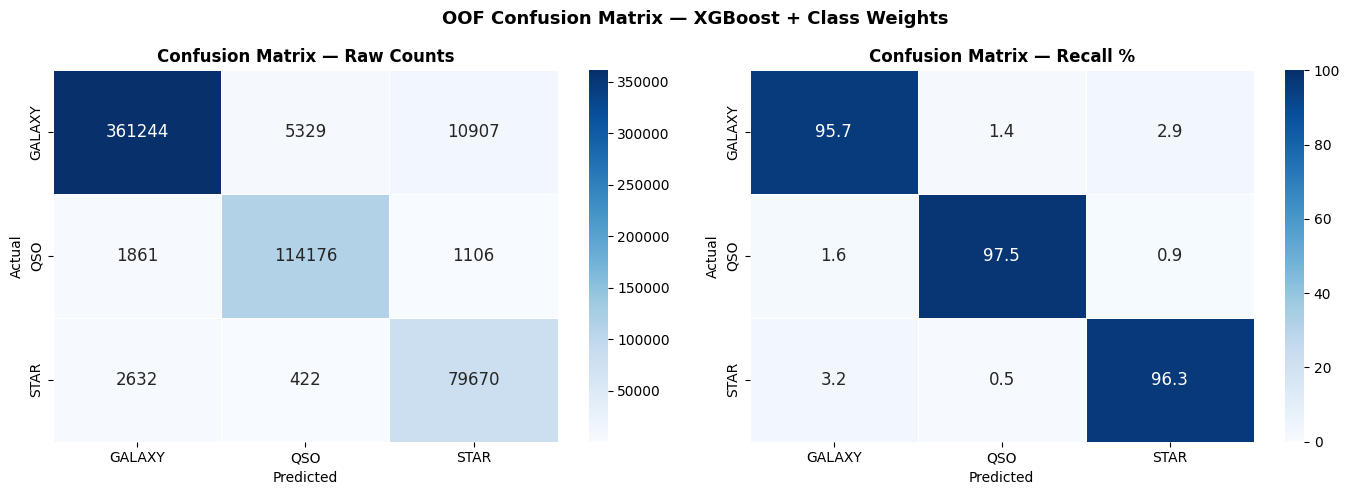

  GALAXY  : 95.70%  (361,244 / 377,480)
  QSO     : 97.47%  (114,176 / 117,143)
  STAR    : 96.31%  (79,670 / 82,724)


In [12]:
y_kag     = y_eval
probs_kag = oof_xgb * global_w
probs_kag = probs_kag / probs_kag.sum(axis=1, keepdims=True)
preds_kag = probs_kag.argmax(axis=1)
train_kag = train_augmented.iloc[kag_idx].reset_index(drop=True)

cm     = confusion_matrix(y_kag, preds_kag)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

print(f'OOF Balanced Accuracy: {oof_score_xgb:.5f}')
print(f'CV  : {np.mean(fold_scores_xgb):.5f} ± {np.std(fold_scores_xgb):.5f}')
print()
print(classification_report(y_kag, preds_kag, target_names=le.classes_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 12})
axes[0].set_title('Confusion Matrix — Raw Counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100,
            annot_kws={'size': 12})
axes[1].set_title('Confusion Matrix — Recall %', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.suptitle('OOF Confusion Matrix — XGBoost + Class Weights',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for i, cls in enumerate(le.classes_):
    print(f'  {cls:8s}: {cm_pct[i,i]:.2f}%  ({cm[i,i]:,} / {cm[i].sum():,})')

## Feature Importance + Calibration

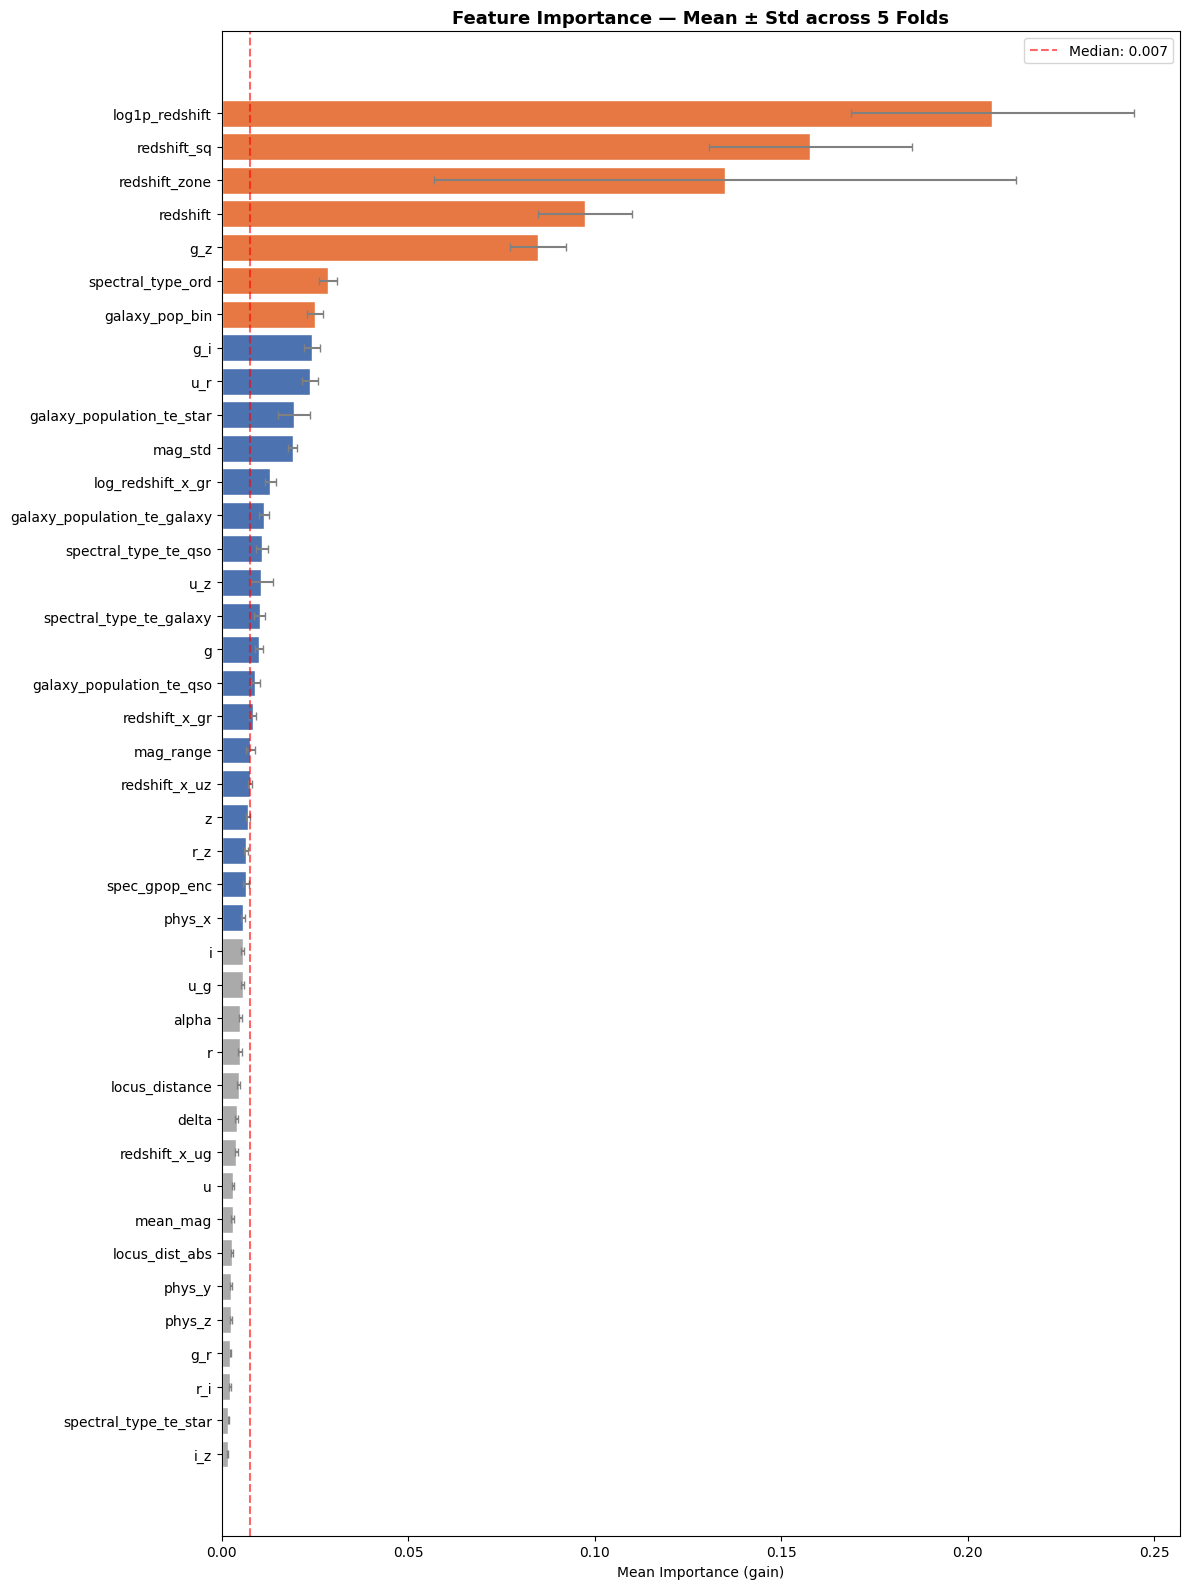

Top 15 features:
log1p_redshift                 0.2066
redshift_sq                    0.1578
redshift_zone                  0.1349
redshift                       0.0974
g_z                            0.0847
spectral_type_ord              0.0286
galaxy_pop_bin                 0.0250
g_i                            0.0242
u_r                            0.0237
galaxy_population_te_star      0.0194
mag_std                        0.0190
log_redshift_x_gr              0.0130
galaxy_population_te_galaxy    0.0113
spectral_type_te_qso           0.0108
u_z                            0.0106

Bottom 10:
redshift_x_ug            0.0039
u                        0.0030
mean_mag                 0.0030
locus_dist_abs           0.0028
phys_y                   0.0024
phys_z                   0.0024
g_r                      0.0023
r_i                      0.0022
spectral_type_te_star    0.0017
i_z                      0.0015


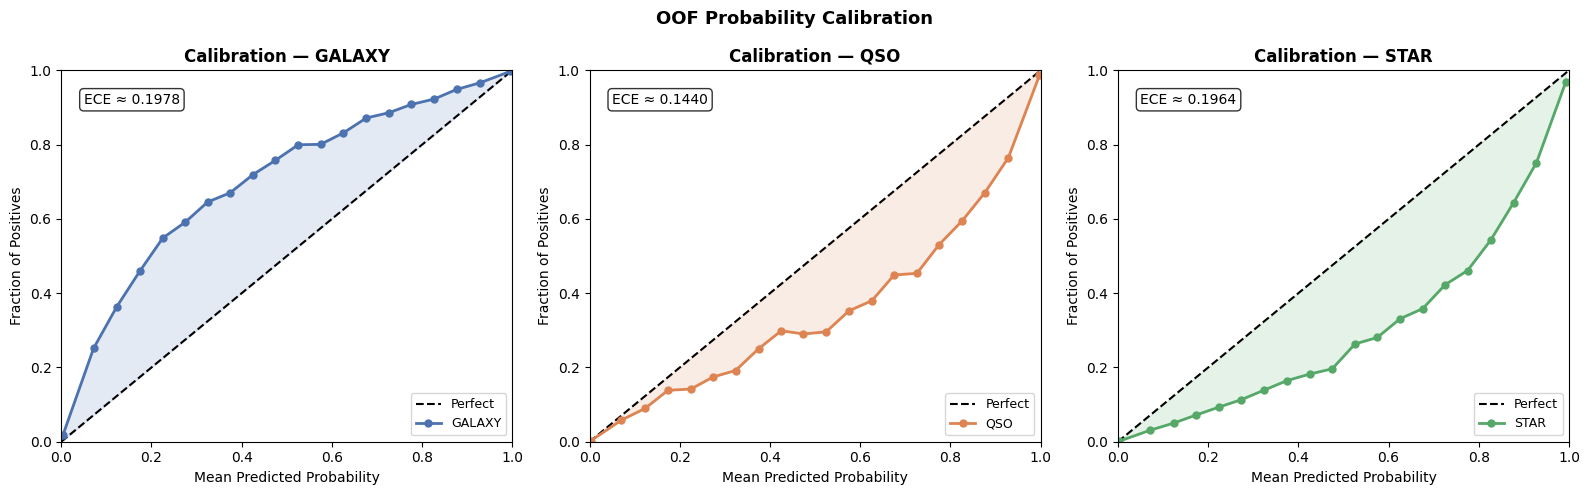

In [13]:
fi_mean = pd.concat(fi_list_xgb, axis=1).mean(axis=1).sort_values(ascending=False)
fi_std  = pd.concat(fi_list_xgb, axis=1).std(axis=1)

fig, ax = plt.subplots(figsize=(12, 16))
bar_colors = [
    '#E87843' if fi_mean[f] >= fi_mean.quantile(0.85) else
    '#4C72B0' if fi_mean[f] >= fi_mean.quantile(0.40) else
    '#AAAAAA'
    for f in fi_mean.index
]
ax.barh(fi_mean.index[::-1], fi_mean.values[::-1],
        xerr=fi_std.reindex(fi_mean.index[::-1]).values,
        color=bar_colors[::-1], edgecolor='white', capsize=3, ecolor='gray')
ax.axvline(fi_mean.median(), color='red', linestyle='--', alpha=0.6,
           label=f'Median: {fi_mean.median():.3f}')
ax.set_xlabel('Mean Importance (gain)')
ax.set_title('Feature Importance — Mean ± Std across 5 Folds',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

print('Top 15 features:')
print(fi_mean.head(15).round(4).to_string())
print('\nBottom 10:')
print(fi_mean.tail(10).round(4).to_string())

y_kag     = y_eval
probs_kag = oof_xgb * global_w
probs_kag = probs_kag / probs_kag.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for cls_idx, cls_name in enumerate(le.classes_):
    ax     = axes[cls_idx]
    y_bin  = (y_kag == cls_idx).astype(int)
    y_prob = probs_kag[:, cls_idx]
    prob_true, prob_pred = calibration_curve(y_bin, y_prob, n_bins=20)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect')
    ax.plot(prob_pred, prob_true, 'o-',
            color=CLASS_COLORS[cls_name], lw=2, ms=5, label=cls_name)
    ax.fill_between(prob_pred, prob_true, prob_pred,
                    alpha=0.15, color=CLASS_COLORS[cls_name])
    ece = np.mean(np.abs(prob_true - prob_pred))
    ax.text(0.05, 0.91, f'ECE ≈ {ece:.4f}', transform=ax.transAxes,
            fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Calibration — {cls_name}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle('OOF Probability Calibration', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Error Analysis

Total errors  : 22,257  (3.86%)
Total correct : 555,090 (96.14%)

Error breakdown by TRUE class:
        n_errors  avg_confidence  median_redshift  pct_of_class
y_true                                                         
GALAXY     16236           0.782            0.120         4.301
QSO         2967           0.819            0.469         2.533
STAR        3054           0.749            0.114         3.692

Top confusion pairs (true → predicted):
               count  avg_confidence  median_redshift  median_gr
y_true y_pred                                                   
GALAXY STAR    10907        0.770449         0.071153   0.758617
       QSO      5329        0.804816         0.903536   0.337928
STAR   GALAXY   2632        0.753874         0.109280   1.191024
QSO    GALAXY   1861        0.822168         0.837119   0.722111
       STAR     1106        0.814673         0.095446   0.251279
STAR   QSO       422        0.721154         0.154514   0.254160


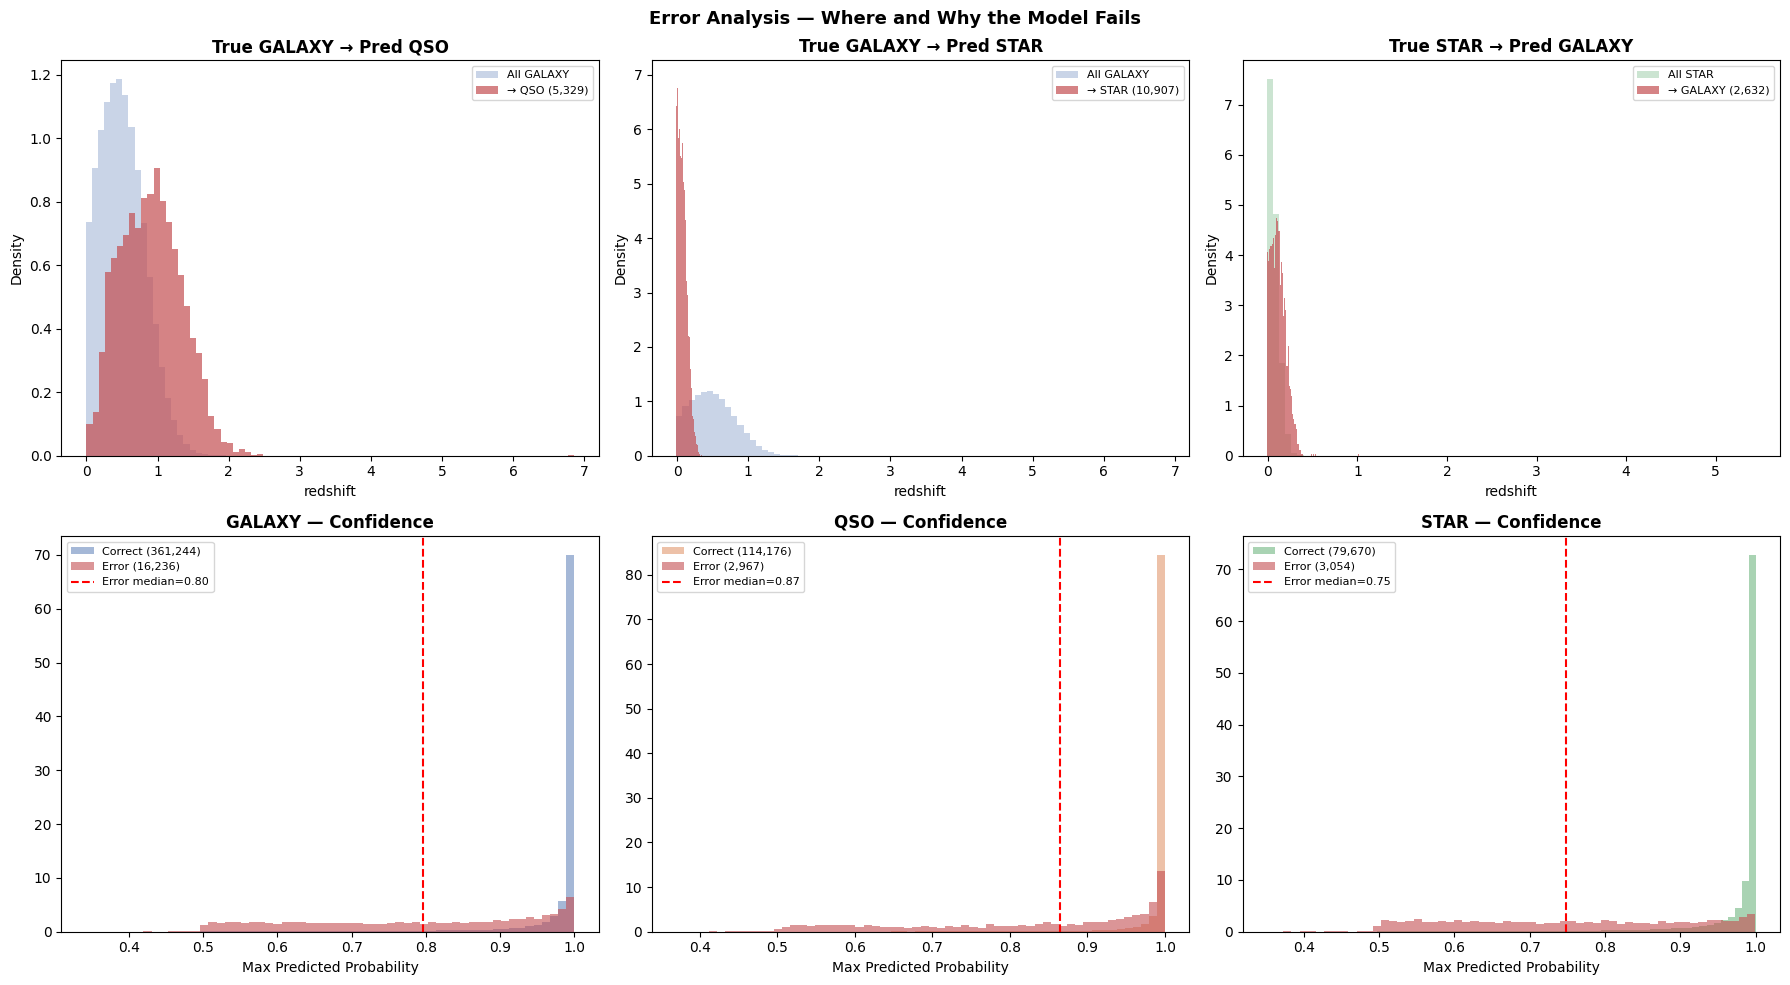

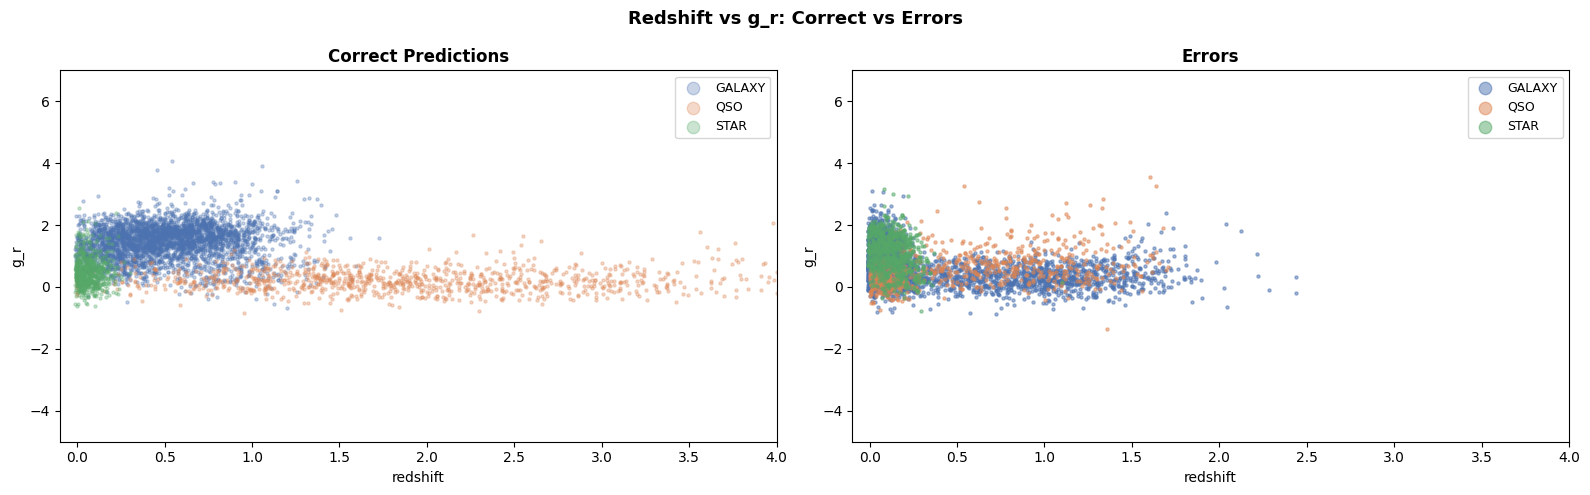


Error rate by redshift bin:
               total  errors  error_rate_%
redshift_bin                              
<0              8957     797          8.90
0–0.15        119359   11292          9.46
0.15–0.5      161484    4450          2.76
0.5–1.0       168547    2816          1.67
1.0–1.5        45815    2309          5.04
1.5–2.5        43678     590          1.35
>2.5           29507       3          0.01


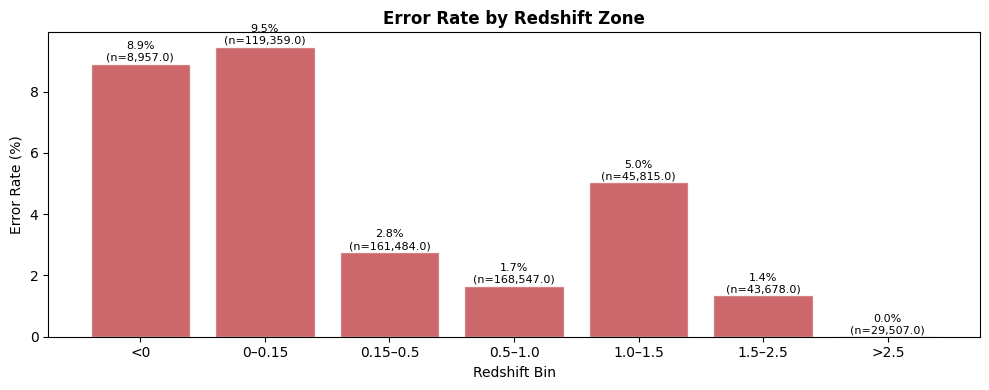

In [14]:
y_kag     = y_eval
probs_kag = oof_xgb * global_w
probs_kag = probs_kag / probs_kag.sum(axis=1, keepdims=True)
preds_kag = probs_kag.argmax(axis=1)
train_kag = train_augmented.iloc[kag_idx].reset_index(drop=True)

error_df = train_kag[['redshift', 'g_r', 'u_g', 'spectral_type',
                       'galaxy_population', 'class']].copy()
error_df['y_true']   = le.inverse_transform(y_kag)
error_df['y_pred']   = le.inverse_transform(preds_kag)
error_df['correct']  = (error_df['y_true'] == error_df['y_pred'])
error_df['max_prob'] = probs_kag.max(axis=1)

errors  = error_df[~error_df['correct']].copy()
correct = error_df[ error_df['correct']].copy()

print(f'Total errors  : {len(errors):,}  ({len(errors)/len(train_kag)*100:.2f}%)')
print(f'Total correct : {len(correct):,} ({len(correct)/len(train_kag)*100:.2f}%)')

print('\nError breakdown by TRUE class:')
err_by_true = errors.groupby('y_true').agg(
    n_errors=('correct', 'count'),
    avg_confidence=('max_prob', 'mean'),
    median_redshift=('redshift', 'median'),
)
err_by_true['pct_of_class'] = [
    len(errors[errors['y_true'] == c]) /
    len(train_kag[train_kag['class'] == c]) * 100
    for c in err_by_true.index
]
print(err_by_true.round(3).to_string())

print('\nTop confusion pairs (true → predicted):')
print(
    errors.groupby(['y_true', 'y_pred'])
    .agg(count=('correct','count'),
         avg_confidence=('max_prob','mean'),
         median_redshift=('redshift','median'),
         median_gr=('g_r','median'))
    .sort_values('count', ascending=False)
    .to_string()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (tc, pc) in zip(axes[0],
        [('GALAXY','QSO'), ('GALAXY','STAR'), ('STAR','GALAXY')]):
    mask    = (errors['y_true'] == tc) & (errors['y_pred'] == pc)
    err_sub = errors[mask]
    ax.hist(train_kag[train_kag['class']==tc]['redshift'], bins=80, alpha=0.3,
            color=CLASS_COLORS[tc], density=True, label=f'All {tc}')
    ax.hist(err_sub['redshift'], bins=80, alpha=0.7,
            color='#C44E52', density=True, label=f'→ {pc} ({len(err_sub):,})')
    ax.set_title(f'True {tc} → Pred {pc}', fontweight='bold')
    ax.set_xlabel('redshift'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for ax, cls in zip(axes[1], CLASS_ORDER):
    mask     = error_df['y_true'] == cls
    err_conf = error_df.loc[mask & ~error_df['correct'], 'max_prob']
    ok_conf  = error_df.loc[mask &  error_df['correct'], 'max_prob']
    ax.hist(ok_conf,  bins=60, alpha=0.5, color=CLASS_COLORS[cls],
            density=True, label=f'Correct ({len(ok_conf):,})')
    ax.hist(err_conf, bins=60, alpha=0.6, color='#C44E52',
            density=True, label=f'Error ({len(err_conf):,})')
    ax.axvline(err_conf.median(), color='red', linestyle='--', lw=1.5,
               label=f'Error median={err_conf.median():.2f}')
    ax.set_title(f'{cls} — Confidence', fontweight='bold')
    ax.set_xlabel('Max Predicted Probability')
    ax.legend(fontsize=8)

plt.suptitle('Error Analysis — Where and Why the Model Fails',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

s_err = errors.sample(min(5000, len(errors)), random_state=42)
s_ok  = correct.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (df, title, a) in zip(axes, [
    (s_ok,  'Correct Predictions', 0.3),
    (s_err, 'Errors',              0.5),
]):
    for cls in CLASS_ORDER:
        sub = df[df['y_true'] == cls]
        ax.scatter(sub['redshift'], sub['g_r'], s=5, alpha=a,
                   color=CLASS_COLORS[cls], label=cls)
    ax.set_xlabel('redshift'); ax.set_ylabel('g_r')
    ax.set_title(title, fontweight='bold')
    ax.legend(markerscale=4, fontsize=9)
    ax.set_xlim(-0.1, 4); ax.set_ylim(-5, 7)

plt.suptitle('Redshift vs g_r: Correct vs Errors',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

error_df['redshift_bin'] = pd.cut(
    error_df['redshift'],
    bins=[-np.inf, 0, 0.15, 0.5, 1.0, 1.5, 2.5, np.inf],
    labels=['<0','0–0.15','0.15–0.5','0.5–1.0','1.0–1.5','1.5–2.5','>2.5']
)
err_rate = (
    error_df.groupby('redshift_bin', observed=True)
    .agg(total=('correct','count'),
         errors=('correct', lambda x: (~x).sum()))
)
err_rate['error_rate_%'] = (err_rate['errors'] / err_rate['total'] * 100).round(2)
print('\nError rate by redshift bin:')
print(err_rate.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(err_rate.index, err_rate['error_rate_%'],
       color='#C44E52', edgecolor='white', alpha=0.85)
for i, (_, row) in enumerate(err_rate.iterrows()):
    ax.text(i, row['error_rate_%'] + 0.1,
            f"{row['error_rate_%']:.1f}%\n(n={row['total']:,})",
            ha='center', fontsize=8)
ax.set_xlabel('Redshift Bin'); ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Redshift Zone', fontweight='bold')
plt.tight_layout(); plt.show()

# Submission

Saved: submission.csv
GALAXY    156923
QSO        51316
STAR       39196
Low-confidence (<60%): 3,762 (1.52%)


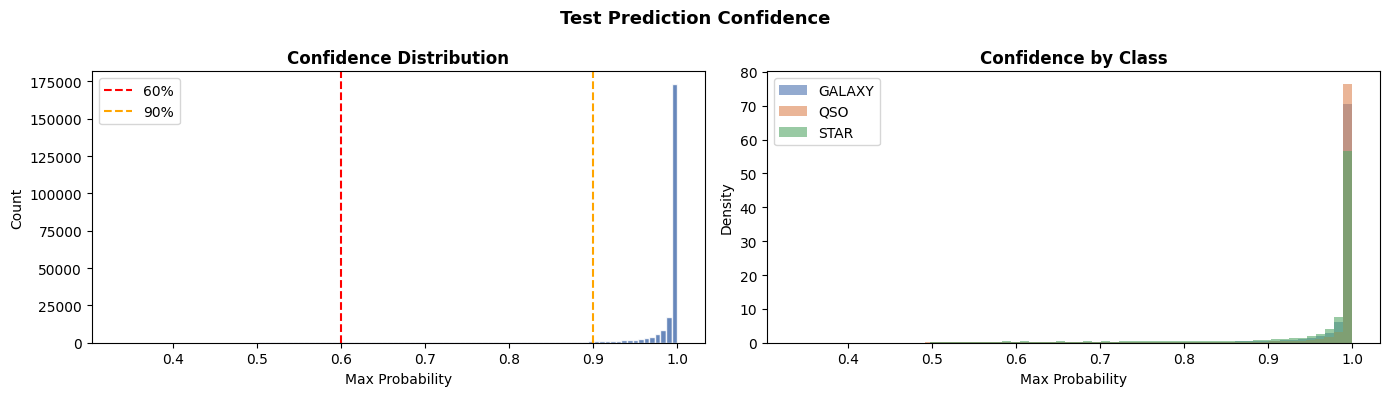


OOF Balanced Accuracy : 0.96343
CV  Balanced Accuracy : 0.96343 ± 0.00020
OOF BA with weights   : 0.96491


In [15]:
labels = le.inverse_transform(test_final.argmax(axis=1))

sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')
sub['class'] = labels
sub.to_csv('submission.csv', index=False)

low_conf = (test_final.max(axis=1) < 0.6).sum()
print(f'Saved: submission.csv')
print(pd.Series(labels).value_counts().to_string())
print(f'Low-confidence (<60%): {low_conf:,} ({low_conf/len(labels)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(test_final.max(axis=1), bins=100,
             color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(0.6, color='red',    linestyle='--', label='60%')
axes[0].axvline(0.9, color='orange', linestyle='--', label='90%')
axes[0].set_xlabel('Max Probability'); axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution', fontweight='bold')
axes[0].legend()

for idx, cls_name in enumerate(le.classes_):
    mask = test_final.argmax(axis=1) == idx
    axes[1].hist(test_final[mask].max(axis=1), bins=60, alpha=0.6,
                 color=CLASS_COLORS[cls_name], density=True, label=cls_name)
axes[1].set_xlabel('Max Probability'); axes[1].set_ylabel('Density')
axes[1].set_title('Confidence by Class', fontweight='bold')
axes[1].legend()
plt.suptitle('Test Prediction Confidence', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'\nOOF Balanced Accuracy : {oof_score_xgb:.5f}')
print(f'CV  Balanced Accuracy : {np.mean(fold_scores_xgb):.5f} ± {np.std(fold_scores_xgb):.5f}')
print(f'OOF BA with weights   : {global_score:.5f}')